# Market Risk Demo

This notebook demonstrates how to use the project after refactoring. The implementation lives in src/; this notebook simply orchestrates the workflow.

In [24]:
import pandas as pd
import numpy as np

In [25]:
from src.config import (
    ASSETS,
    INDICES,
    FX,
    ALL_INSTRUMENTS,
    WEIGHTS,
    PORTFOLIO_VALUE, 
    SCENARIOS,
    STRESS_RHO,
    IN_SAMPLE_START,
    IN_SAMPLE_END,
    BACKTEST_START,
    BACKTEST_END,
    lam,
    alpha,
    backtest_sig
)

from src.data import (
    load_prices,
    split_sample
)

from src.volatility import (
    ewma_volatility,
    fit_garch,
    forecast_garch_vol
)

from src.portfolio import (
    correlation_matrix,
    portfolio_volatility_assets,
    estimate_capm_betas,
    portfolio_volatility_capm,
    portfolio_return_series
)

from src.var_models import (
normal_var_es,
student_t_var_es,
fit_student_t_dof
)

from src.backtest import (
    kupiec_test
)

from src.run_model import (
    run,
    print_headline_table
)

In [26]:
prices, log_returns = load_prices("data/data.csv")

In [27]:
results = run(log_returns)

In [28]:
summary = results["summary"]

returns = results["returns"]
in_sample = results["in_sample"]
backtest = results["backtest"]

portfolio_returns = results["portfolio_returns"]

ewma_asset_vol = results["ewma_asset_volatility"]
ewma_portfolio_vol = results["ewma_portfolio_volatility"]
capm_portfolio_volatility =  results["capm_portfolio_volatility"]

garch_conditional_vol = results["garch_conditional_volatility"]
garch_parameters = results["garch_parameters"]

asset_corr = results["asset_corr"]
index_corr = results["index_corr"]

var_results = results["var_results"]

In [29]:
print_headline_table(summary, backtest_sig)


=== VaR Backtest Summary ===
                  total_observations  total_breaches avg_breach_rate expected_breach_rate kupiec_pass_rate
model scenario                                                                                            
A     historical                1043              21           2.01%                5.00%            2 / 4
      stress                    1043               8           0.77%                5.00%            4 / 4
      zero                      1043              52           4.98%                5.00%            1 / 4
B     historical                1043              48            4.6%                5.00%            0 / 4
      stress                    1043              36           3.45%                5.00%            0 / 4
      zero                      1043              87           8.34%                5.00%            0 / 4
C     historical                1043              17           1.63%                5.00%            3 / 4
      s

# Testing

In [30]:
from src.model_validation import (
    run_all_checks
)

In [31]:
garch_alpha = garch_parameters['SPX']['alpha']
garch_beta = garch_parameters['SPX']['beta']
normal_var = results['var_results']['VaR_A']
t_var = results['var_results']['VaR_C']

In [32]:
run_all_checks(
    returns,
    summary,
    ewma_asset_vol,
    garch_alpha,
    garch_beta,
    WEIGHTS,
    normal_var,
    t_var   
)

=== Return Checks ===
shape              (3952, 6)
missing_values             0
infinite_values            0
sorted_index            True
dtype: object
=== Return Statistics ===
           NKE         C       SPX       CBK       VOW       DAX
mean  0.000466  0.000274  0.000480 -0.000164  0.000075  0.000315
std   0.017244  0.020507  0.010561  0.026170  0.020884  0.012346
min  -0.223410 -0.214046 -0.127284 -0.179019 -0.188116 -0.118168
max   0.147431  0.188856  0.112283  0.163651  0.198934  0.090572
=== Portfolio Weights ===
{'total_weight': 1.0, 'weights_sum_to_one': np.True_}
=== EWMA Checks ===
shape            (3952, 4)
min_vol           0.006848
max_vol            0.09393
negative_vols            0
nan_values               0
dtype: object
=== EWMA Recursion Error ===
2.168404344971009e-19
=== GARCH Parameter Persistence ===
{'alpha': np.float64(0.1268587592055338), 'beta': np.float64(0.8252388029069738), 'persistence': np.float64(0.9520975621125076), 'stationary': np.True_}
=== VaR 

# Visualisations

In [33]:
from src.visualisations import (
    plot_asset_prices,
    plot_return_series,
    plot_return_distribution,
    plot_ewma_volatility,
    plot_garch_volatility,
    plot_correlation_heatmap,
    plot_portfolio_volatility,
    plot_var_backtest,
    plot_kupiec_results
)

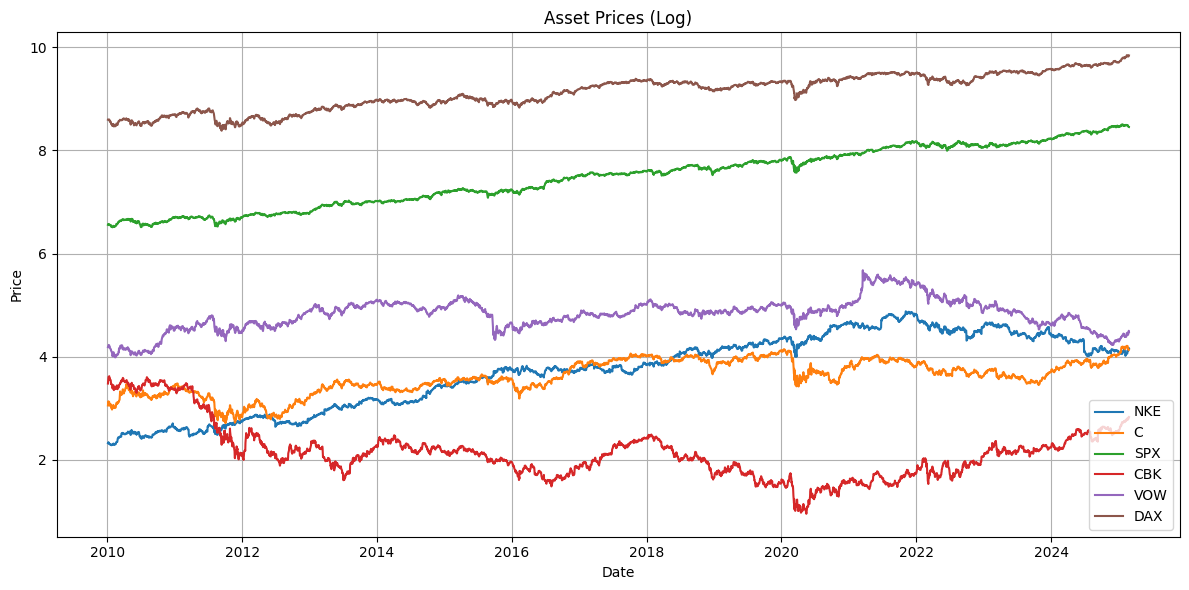

In [34]:
plot_asset_prices(prices)

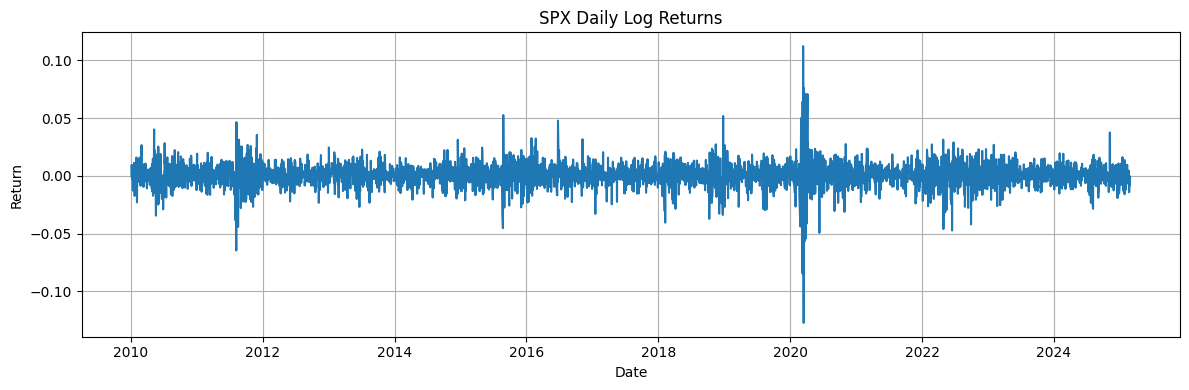

In [35]:
plot_return_series(
    results["returns"],
    "SPX"
)

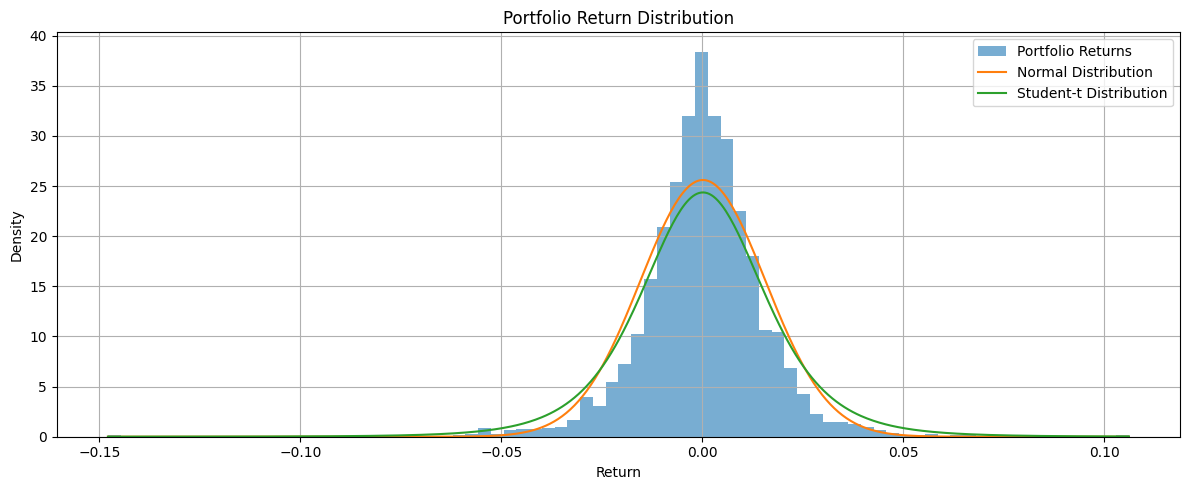

In [36]:
plot_return_distribution(
    results["portfolio_returns"]
)

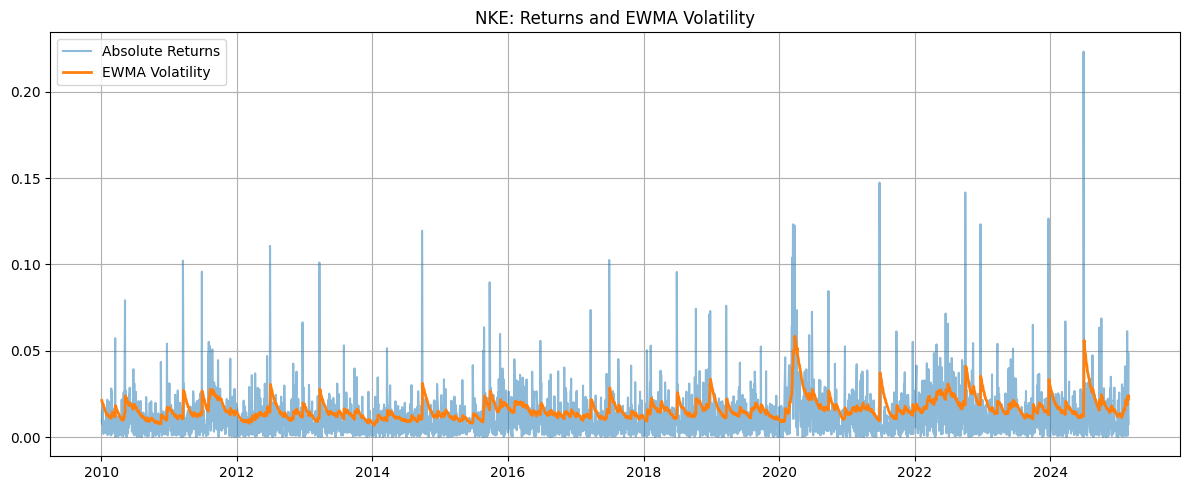

In [37]:
plot_ewma_volatility(
    results["returns"],
    results["ewma_asset_volatility"],
    "NKE"
)

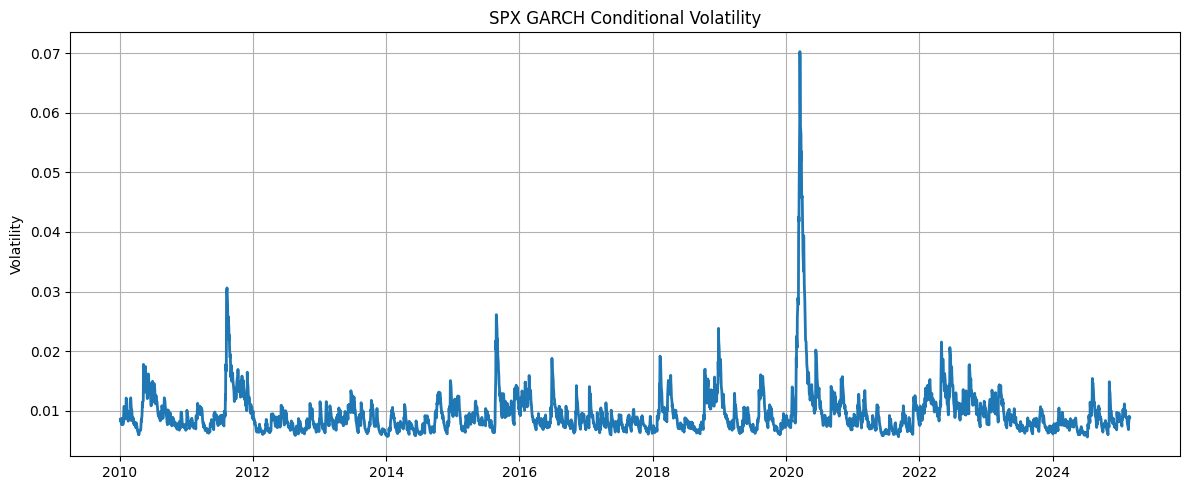

In [38]:
plot_garch_volatility(
    results["garch_conditional_volatility"],
    "SPX"
)

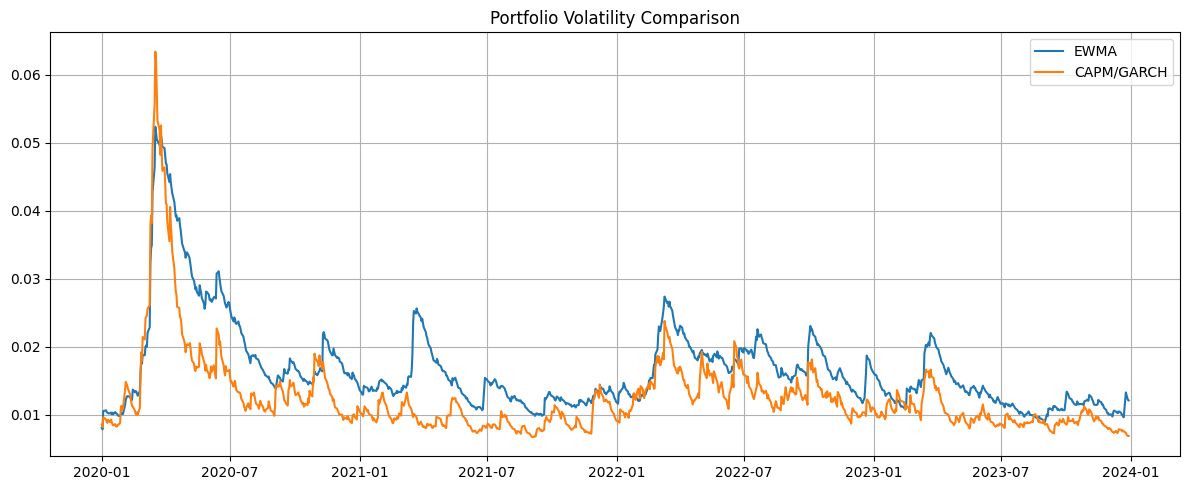

In [39]:
plot_portfolio_volatility(
    results["ewma_portfolio_volatility"],
    results["capm_portfolio_volatility"]
)

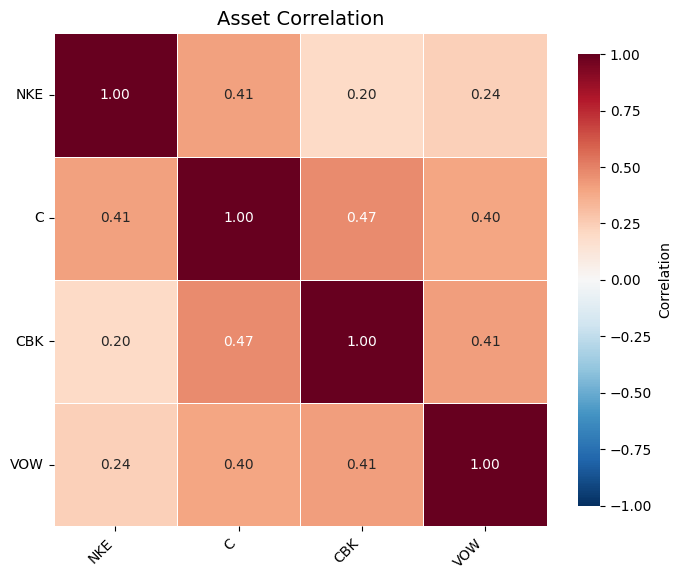

In [40]:
plot_correlation_heatmap(asset_corr, "Asset Correlation")

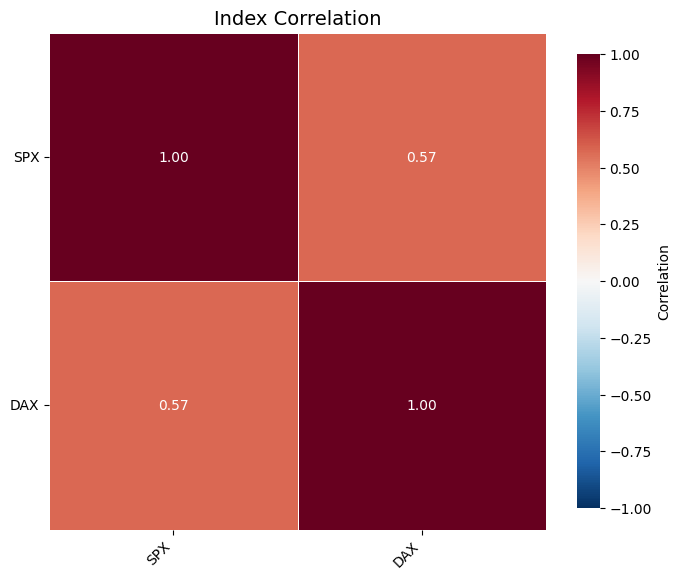

In [46]:
plot_correlation_heatmap(index_corr, "Index Correlation")

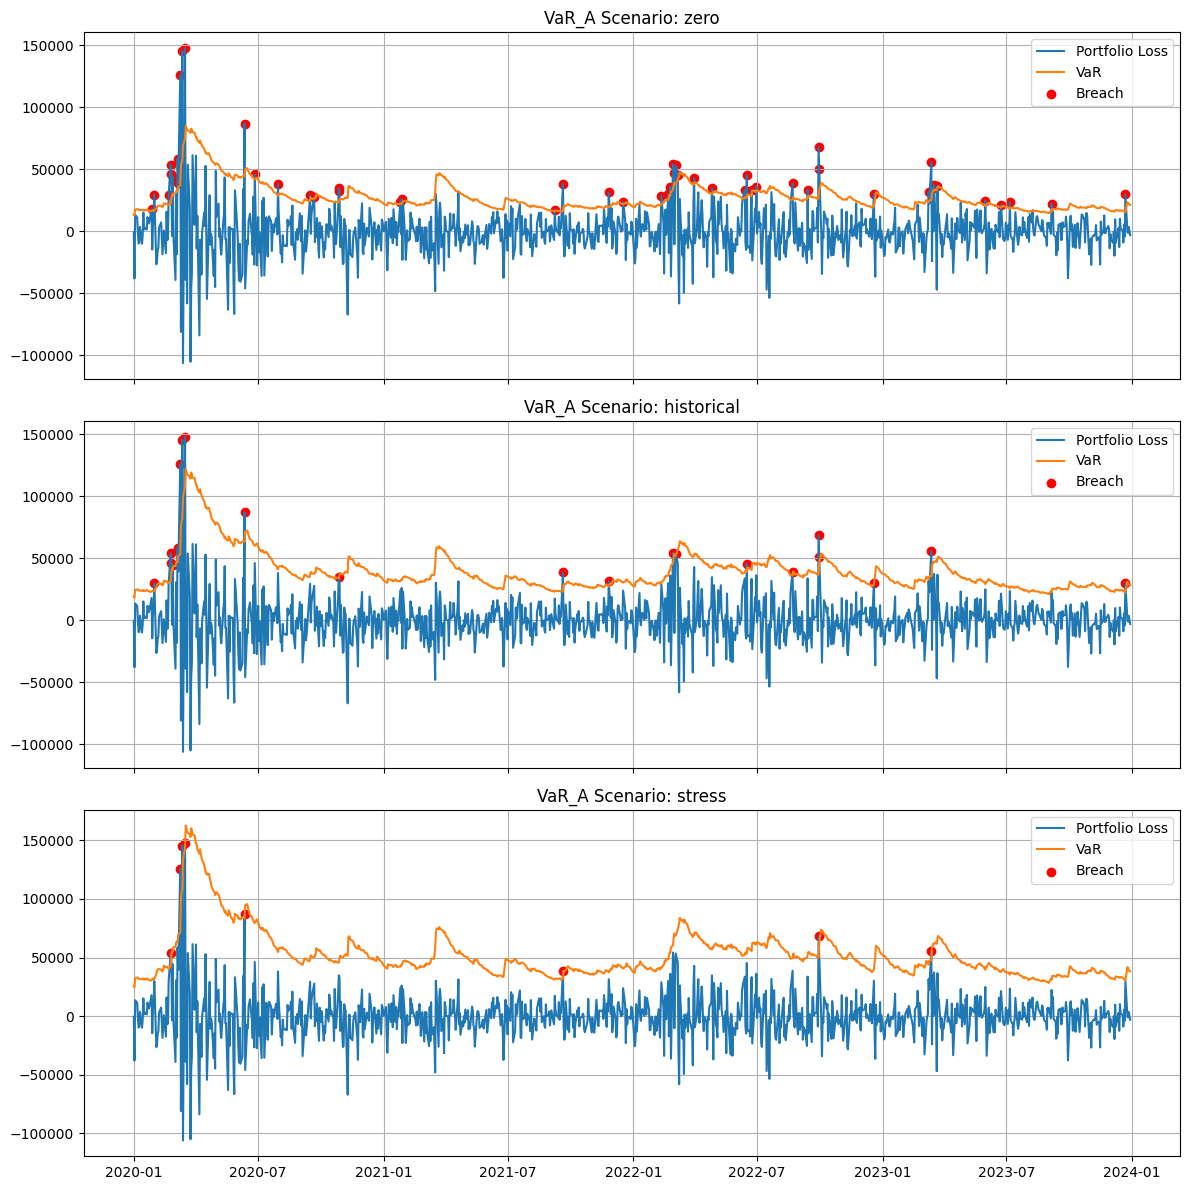

In [42]:
plot_var_backtest(
    results["var_results"],
    "A"
)

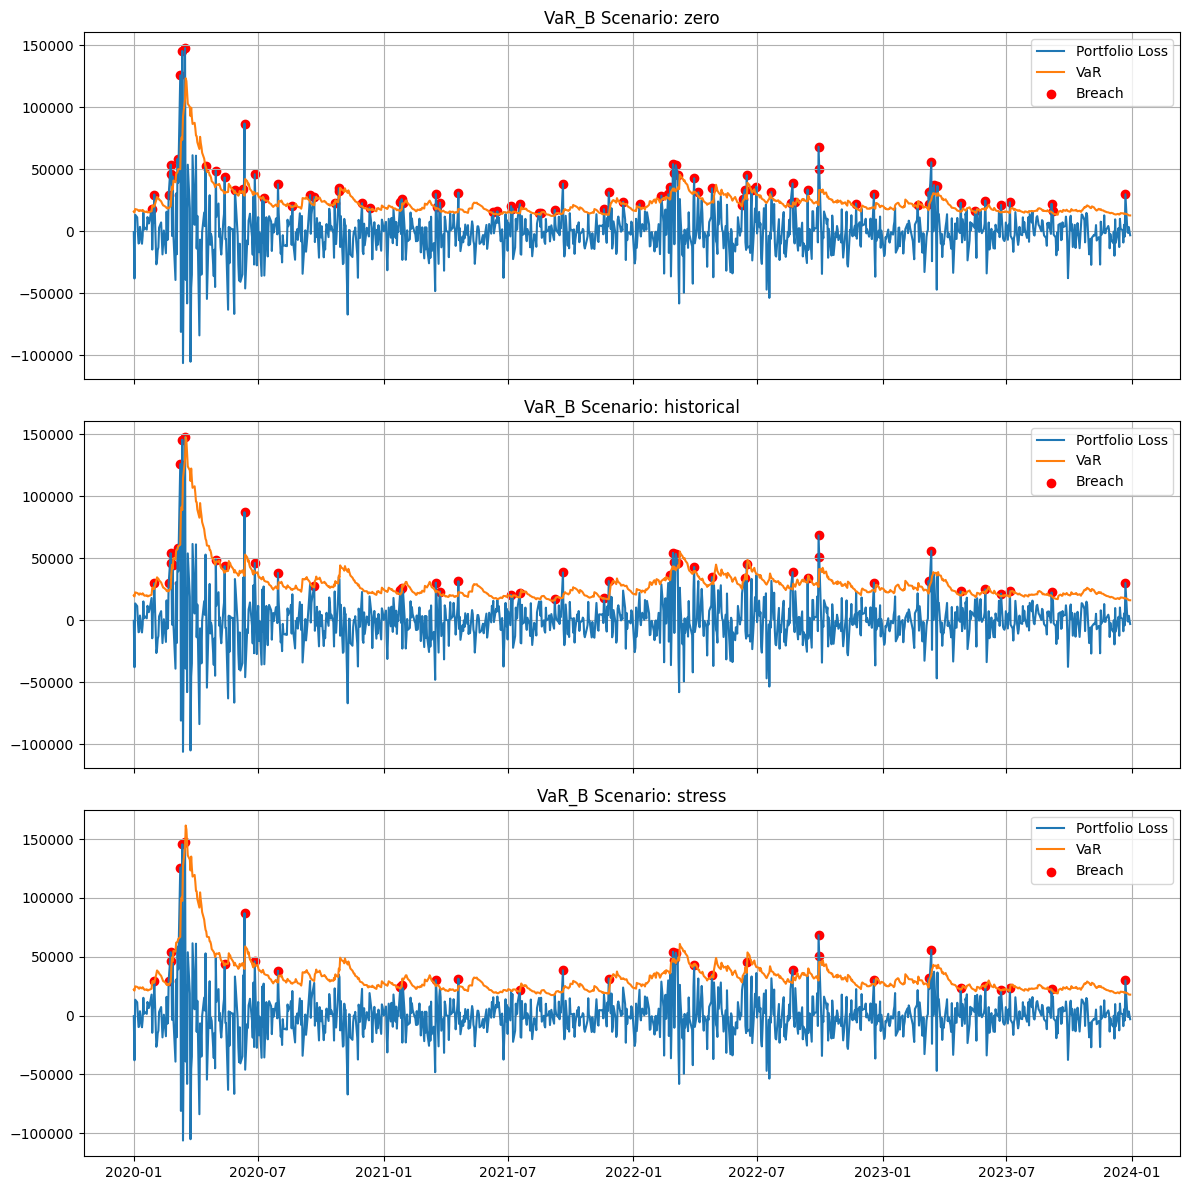

In [43]:
plot_var_backtest(
    results["var_results"],
    "B"
)

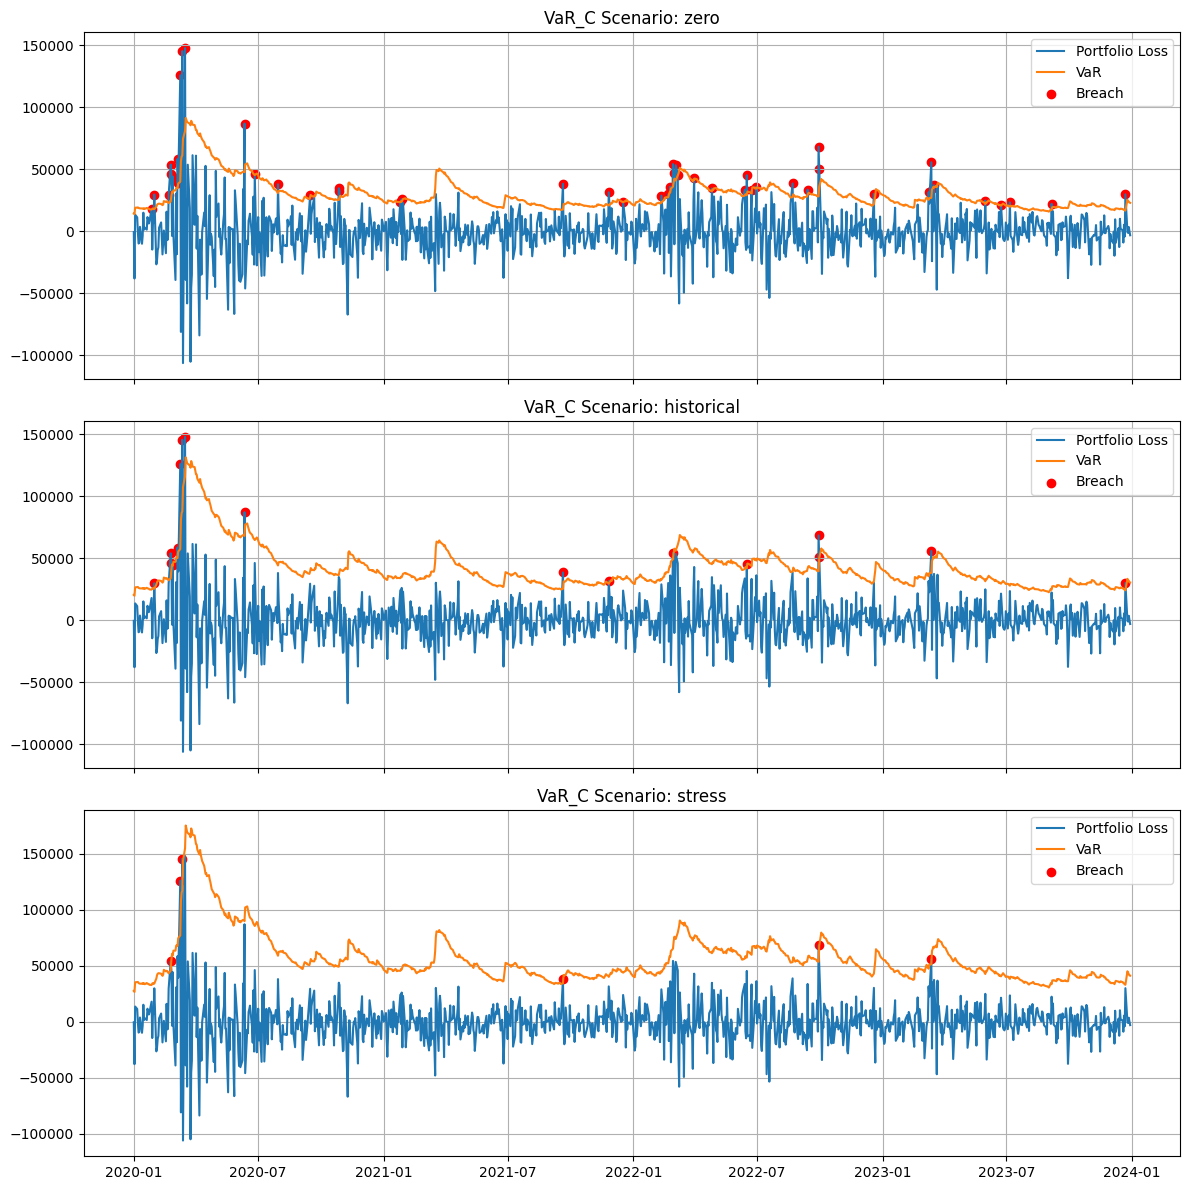

In [44]:
plot_var_backtest(
    results["var_results"],
    "C"
)

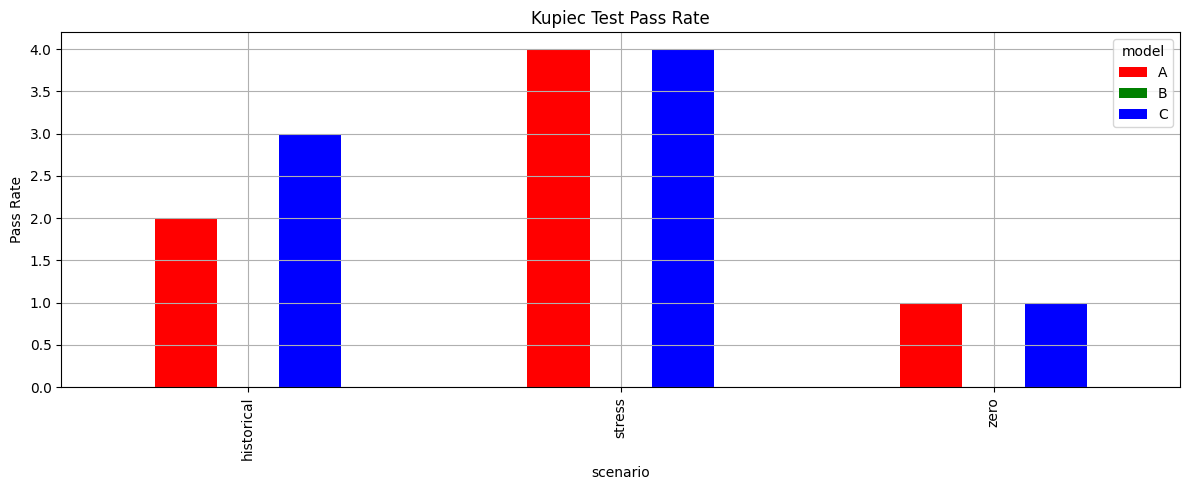

In [45]:
plot_kupiec_results(summary)